In [4]:
import numpy as np
import pandas as pd
pd.options.display.max_columns=20 #DataFrameの表示の際に、最大20列まで表示
pd.options.display.max_rows=20     #DataFrameの表示の際に、最大20行まで表示
pd.options.display.max_colwidth=80 #1つのセルに表示される文字数を最大80文字に制限
np.set_printoptions(precision=4,suppress=True) #小数点以下4桁まで表示かつ非常に小さい数を指数表記(e-05 とか)にしない

In [5]:
from datetime import datetime

In [6]:
now=datetime.now()

In [7]:
now

datetime.datetime(2026, 3, 27, 16, 10, 40, 908930)

In [8]:
now.year,now.month,now.day

(2026, 3, 27)

In [9]:
delta=datetime(2011,1,7)-datetime(2008,6,24,8,15)

In [10]:
delta

datetime.timedelta(days=926, seconds=56700)

In [11]:
delta.days

926

In [12]:
delta.seconds

56700

In [13]:
from datetime import timedelta

In [14]:
start=datetime(2011,1,7)

In [15]:
start+timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

In [16]:
start-2*timedelta(12)

datetime.datetime(2010, 12, 14, 0, 0)

In [17]:
stamp=datetime(2011,1,3)

In [18]:
str(stamp)

'2011-01-03 00:00:00'

In [19]:
stamp.strftime("%Y-%m-%d")

'2011-01-03'

In [20]:
value="2011-01-03"

In [21]:
datetime.strptime(value,"%Y-%m-%d")

datetime.datetime(2011, 1, 3, 0, 0)

In [22]:
datestrs=["7/6/2011","8/6/2011"]

In [23]:
[datetime.strptime(x,"%m/%d/%Y") for x in datestrs]

[datetime.datetime(2011, 7, 6, 0, 0), datetime.datetime(2011, 8, 6, 0, 0)]

In [24]:
datestrs=["2011-07-06 12:00:00","2011-08-06 00:00:00"]

In [25]:
pd.to_datetime(datestrs)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)

In [26]:
idx=pd.to_datetime(datestrs+[None])

In [27]:
idx

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00', 'NaT'], dtype='datetime64[ns]', freq=None)

In [28]:
idx[2]

NaT

In [29]:
pd.isna(idx)

array([False, False,  True])

In [30]:
dates=[datetime(2011,1,2),datetime(2011,1,5),datetime(2011,1,7),
      datetime(2011,1,8),datetime(2011,1,10),datetime(2011,1,12)]

In [31]:
ts=pd.Series(np.random.standard_normal(6),index=dates)

In [32]:
ts

2011-01-02    0.428954
2011-01-05   -0.505779
2011-01-07    0.764559
2011-01-08    1.496464
2011-01-10   -1.719981
2011-01-12   -0.654907
dtype: float64

In [33]:
ts.index

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

In [34]:
ts+ts[::2]

2011-01-02    0.857908
2011-01-05         NaN
2011-01-07    1.529118
2011-01-08         NaN
2011-01-10   -3.439961
2011-01-12         NaN
dtype: float64

In [35]:
ts.index.dtype

dtype('<M8[ns]')

In [36]:
stamps=ts.index[0]

In [37]:
stamps

Timestamp('2011-01-02 00:00:00')

In [38]:
stamps=ts.index[2]

In [39]:
ts[stamps]

np.float64(0.7645588325876352)

In [40]:
ts["2011-01-10"]

np.float64(-1.7199805227629452)

In [41]:
longer_ts=pd.Series(np.random.standard_normal(1000),
                   index=pd.date_range("2000-01-01",periods=1000))

In [42]:
longer_ts

2000-01-01   -0.686966
2000-01-02    1.435798
2000-01-03    0.128146
2000-01-04   -0.793228
2000-01-05   -0.939032
                ...   
2002-09-22    0.360629
2002-09-23    1.088978
2002-09-24   -1.323079
2002-09-25    0.870688
2002-09-26   -0.275101
Freq: D, Length: 1000, dtype: float64

In [43]:
longer_ts["2001"]

2001-01-01    1.854417
2001-01-02    1.609846
2001-01-03   -0.961878
2001-01-04    0.170321
2001-01-05   -0.803917
                ...   
2001-12-27   -0.338156
2001-12-28   -0.352382
2001-12-29   -0.911593
2001-12-30    1.715005
2001-12-31    0.064899
Freq: D, Length: 365, dtype: float64

In [44]:
longer_ts["2001-05"]

2001-05-01   -1.060446
2001-05-02    1.062243
2001-05-03    1.556128
2001-05-04   -0.955744
2001-05-05    1.752537
                ...   
2001-05-27    1.152814
2001-05-28    1.428837
2001-05-29    1.057662
2001-05-30   -1.137146
2001-05-31    0.770419
Freq: D, Length: 31, dtype: float64

In [45]:
ts[datetime(2011,1,7):]

2011-01-07    0.764559
2011-01-08    1.496464
2011-01-10   -1.719981
2011-01-12   -0.654907
dtype: float64

In [46]:
ts[datetime(2011,1,7):datetime(2011,1,10)]

2011-01-07    0.764559
2011-01-08    1.496464
2011-01-10   -1.719981
dtype: float64

In [47]:
ts

2011-01-02    0.428954
2011-01-05   -0.505779
2011-01-07    0.764559
2011-01-08    1.496464
2011-01-10   -1.719981
2011-01-12   -0.654907
dtype: float64

In [48]:
ts["2011-01-06":"2011-01-11"]

2011-01-07    0.764559
2011-01-08    1.496464
2011-01-10   -1.719981
dtype: float64

In [49]:
ts.truncate(after="2011-01-09")

2011-01-02    0.428954
2011-01-05   -0.505779
2011-01-07    0.764559
2011-01-08    1.496464
dtype: float64

In [50]:
dates=pd.date_range("2011-01-01",periods=100,freq="W-WED")

In [51]:
long_df=pd.DataFrame(np.random.standard_normal((100,4)),
                    index=dates,
                    columns=["Colorado","Texas","New York","Ohio"])

In [52]:
long_df.loc["2011-05"]

,Colorado,Texas,New York,Ohio
2011-05-04,1.517753,-0.502347,1.840848,0.338631
2011-05-11,0.247652,-1.057284,-0.735383,0.546908
2011-05-18,1.553840,1.739431,0.775119,2.412629
2011-05-25,0.525597,-1.231819,-0.594338,1.015500


In [53]:
dates=pd.DatetimeIndex(["2000-01-01","2000-01-02","2000-01-02","2000-01-02","2000-01-03"])

In [54]:
dup_ts=pd.Series(np.arange(5),index=dates)

In [55]:
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

In [56]:
dup_ts.index.is_unique

False

In [57]:
dup_ts["2000-01-03"]

np.int64(4)

In [58]:
dup_ts["2000-01-02"]

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

In [59]:
grouped=dup_ts.groupby(level=0)

In [60]:
grouped.mean()

2000-01-01    0.0
2000-01-02    2.0
2000-01-03    4.0
dtype: float64

In [61]:
grouped.count()

2000-01-01    1
2000-01-02    3
2000-01-03    1
dtype: int64

In [62]:
ts

2011-01-02    0.428954
2011-01-05   -0.505779
2011-01-07    0.764559
2011-01-08    1.496464
2011-01-10   -1.719981
2011-01-12   -0.654907
dtype: float64

In [63]:
resampler=ts.resample("D")

In [64]:
resampler

In [65]:
index=pd.date_range("2012-04-01","2012-06-01")

In [66]:
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

In [67]:
pd.date_range(start="2012-04-01",periods=20)

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[ns]', freq='D')

In [68]:
pd.date_range(end="2012-06-01",periods=20)

DatetimeIndex(['2012-05-13', '2012-05-14', '2012-05-15', '2012-05-16',
               '2012-05-17', '2012-05-18', '2012-05-19', '2012-05-20',
               '2012-05-21', '2012-05-22', '2012-05-23', '2012-05-24',
               '2012-05-25', '2012-05-26', '2012-05-27', '2012-05-28',
               '2012-05-29', '2012-05-30', '2012-05-31', '2012-06-01'],
              dtype='datetime64[ns]', freq='D')

In [69]:
pd.date_range("2000-01-01","2000-12-01",freq="BME")

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[ns]', freq='BME')

In [70]:
pd.date_range("2012-05-02 12:56:31",periods=5)

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[ns]', freq='D')

In [71]:
pd.date_range("2012-05-02 12:56:31",periods=5,normalize=True)

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[ns]', freq='D')

In [72]:
from pandas.tseries.offsets import Hour,Minute

In [73]:
hour=Hour()

In [74]:
hour

<Hour>

In [75]:
four_hours=Hour(4)

In [76]:
four_hours

<4 * Hours>

In [77]:
pd.date_range("2000-01-01","2000-01-03 23:59",freq=four_hours)

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[ns]', freq='4h')

In [78]:
Hour(2)+Minute(30)

<150 * Minutes>

In [79]:
pd.date_range("2000-01-01",periods=10,freq="1h30min")

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[ns]', freq='90min')

In [80]:
monthly_dates=pd.date_range("2012-01-01","2012-09-01",freq="WOM-3FRI")

In [81]:
list(monthly_dates)

[Timestamp('2012-01-20 00:00:00'),
 Timestamp('2012-02-17 00:00:00'),
 Timestamp('2012-03-16 00:00:00'),
 Timestamp('2012-04-20 00:00:00'),
 Timestamp('2012-05-18 00:00:00'),
 Timestamp('2012-06-15 00:00:00'),
 Timestamp('2012-07-20 00:00:00'),
 Timestamp('2012-08-17 00:00:00')]

In [82]:
ts=pd.Series(np.random.standard_normal(4),
            index=pd.date_range("2000-01-01",periods=4,freq="ME"))

In [83]:
ts

2000-01-31   -0.284135
2000-02-29   -1.160583
2000-03-31    0.854714
2000-04-30   -1.416217
Freq: ME, dtype: float64

In [84]:
ts.shift(2)

2000-01-31         NaN
2000-02-29         NaN
2000-03-31   -0.284135
2000-04-30   -1.160583
Freq: ME, dtype: float64

In [85]:
ts.shift(-2)

2000-01-31    0.854714
2000-02-29   -1.416217
2000-03-31         NaN
2000-04-30         NaN
Freq: ME, dtype: float64

In [86]:
ts/ts.shift(1)-1

2000-01-31         NaN
2000-02-29    3.084618
2000-03-31   -1.736453
2000-04-30   -2.656948
Freq: ME, dtype: float64

In [87]:
ts.shift(2,freq="ME")

2000-03-31   -0.284135
2000-04-30   -1.160583
2000-05-31    0.854714
2000-06-30   -1.416217
Freq: ME, dtype: float64

In [88]:
ts.shift(3,freq="D")

2000-02-03   -0.284135
2000-03-03   -1.160583
2000-04-03    0.854714
2000-05-03   -1.416217
dtype: float64

In [89]:
ts.shift(1,freq="90min")

2000-01-31 01:30:00   -0.284135
2000-02-29 01:30:00   -1.160583
2000-03-31 01:30:00    0.854714
2000-04-30 01:30:00   -1.416217
dtype: float64

In [90]:
from pandas.tseries.offsets import Day,MonthEnd

In [91]:
now=datetime(2011,11,17)

In [92]:
now+3*Day()

Timestamp('2011-11-20 00:00:00')

In [93]:
now+MonthEnd(2)

Timestamp('2011-12-31 00:00:00')

In [94]:
offset=MonthEnd()

In [95]:
offset.rollforward(now)

Timestamp('2011-11-30 00:00:00')

In [96]:
offset.rollback(now)

Timestamp('2011-10-31 00:00:00')

In [97]:
ts=pd.Series(np.random.standard_normal(20),
            index=pd.date_range("2000-01-15",periods=20,freq="4D"))

In [98]:
ts

2000-01-15   -0.630486
2000-01-19   -0.169464
2000-01-23    0.896204
2000-01-27   -0.075186
2000-01-31   -0.390887
2000-02-04    0.109210
2000-02-08    0.625736
2000-02-12   -0.477165
2000-02-16    0.003944
2000-02-20    0.106157
2000-02-24   -0.311634
2000-02-28    1.913862
2000-03-03   -0.513429
2000-03-07   -0.266744
2000-03-11    0.258396
2000-03-15    0.361713
2000-03-19    0.573824
2000-03-23    0.436592
2000-03-27   -1.039789
2000-03-31   -0.854170
Freq: 4D, dtype: float64

In [99]:
ts.groupby(MonthEnd().rollforward).mean()

2000-01-31   -0.073964
2000-02-29    0.281444
2000-03-31   -0.130451
dtype: float64

In [100]:
ts.resample("ME").mean()

2000-01-31   -0.073964
2000-02-29    0.281444
2000-03-31   -0.130451
Freq: ME, dtype: float64

In [101]:
import pytz

In [102]:
pytz.common_timezones[-5:]

['US/Eastern', 'US/Hawaii', 'US/Mountain', 'US/Pacific', 'UTC']

In [103]:
tz=pytz.timezone("America/New_York")

In [104]:
tz

<DstTzInfo 'America/New_York' LMT-1 day, 19:04:00 STD>

In [105]:
dates=pd.date_range("2012-03-09 09:30",periods=6)

In [106]:
ts=pd.Series(np.random.standard_normal(len(dates)),index=dates)

In [107]:
ts

2012-03-09 09:30:00   -0.122158
2012-03-10 09:30:00    0.229616
2012-03-11 09:30:00    0.467520
2012-03-12 09:30:00   -0.965812
2012-03-13 09:30:00   -0.852083
2012-03-14 09:30:00    0.667042
Freq: D, dtype: float64

In [108]:
print(ts.index.tz)

None


In [109]:
pd.date_range("2012-03-09 09:30",periods=10,tz="UTC")

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00',
               '2012-03-15 09:30:00+00:00', '2012-03-16 09:30:00+00:00',
               '2012-03-17 09:30:00+00:00', '2012-03-18 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [110]:
ts

2012-03-09 09:30:00   -0.122158
2012-03-10 09:30:00    0.229616
2012-03-11 09:30:00    0.467520
2012-03-12 09:30:00   -0.965812
2012-03-13 09:30:00   -0.852083
2012-03-14 09:30:00    0.667042
Freq: D, dtype: float64

In [111]:
ts_utc=ts.tz_localize("UTC")

In [112]:
ts_utc

2012-03-09 09:30:00+00:00   -0.122158
2012-03-10 09:30:00+00:00    0.229616
2012-03-11 09:30:00+00:00    0.467520
2012-03-12 09:30:00+00:00   -0.965812
2012-03-13 09:30:00+00:00   -0.852083
2012-03-14 09:30:00+00:00    0.667042
Freq: D, dtype: float64

In [113]:
ts_utc.index

DatetimeIndex(['2012-03-09 09:30:00+00:00', '2012-03-10 09:30:00+00:00',
               '2012-03-11 09:30:00+00:00', '2012-03-12 09:30:00+00:00',
               '2012-03-13 09:30:00+00:00', '2012-03-14 09:30:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='D')

In [114]:
ts_utc.tz_convert("America/New_York")

2012-03-09 04:30:00-05:00   -0.122158
2012-03-10 04:30:00-05:00    0.229616
2012-03-11 05:30:00-04:00    0.467520
2012-03-12 05:30:00-04:00   -0.965812
2012-03-13 05:30:00-04:00   -0.852083
2012-03-14 05:30:00-04:00    0.667042
Freq: D, dtype: float64

In [115]:
ts_eastern=ts.tz_localize("America/New_York")

In [116]:
ts_eastern

2012-03-09 09:30:00-05:00   -0.122158
2012-03-10 09:30:00-05:00    0.229616
2012-03-11 09:30:00-04:00    0.467520
2012-03-12 09:30:00-04:00   -0.965812
2012-03-13 09:30:00-04:00   -0.852083
2012-03-14 09:30:00-04:00    0.667042
dtype: float64

In [117]:
ts_eastern.tz_convert("UTC")

2012-03-09 14:30:00+00:00   -0.122158
2012-03-10 14:30:00+00:00    0.229616
2012-03-11 13:30:00+00:00    0.467520
2012-03-12 13:30:00+00:00   -0.965812
2012-03-13 13:30:00+00:00   -0.852083
2012-03-14 13:30:00+00:00    0.667042
dtype: float64

In [118]:
ts_eastern.tz_convert("Europe/Berlin")

2012-03-09 15:30:00+01:00   -0.122158
2012-03-10 15:30:00+01:00    0.229616
2012-03-11 14:30:00+01:00    0.467520
2012-03-12 14:30:00+01:00   -0.965812
2012-03-13 14:30:00+01:00   -0.852083
2012-03-14 14:30:00+01:00    0.667042
dtype: float64

In [119]:
ts.index.tz_localize("Asia/Shanghai")

DatetimeIndex(['2012-03-09 09:30:00+08:00', '2012-03-10 09:30:00+08:00',
               '2012-03-11 09:30:00+08:00', '2012-03-12 09:30:00+08:00',
               '2012-03-13 09:30:00+08:00', '2012-03-14 09:30:00+08:00'],
              dtype='datetime64[ns, Asia/Shanghai]', freq=None)

In [120]:
stamps=pd.Timestamp("2011-03-12 04:00")

In [121]:
stamps_utc=stamps.tz_localize("UTC")

In [122]:
stamps_utc.tz_convert("America/New_York")

Timestamp('2011-03-11 23:00:00-0500', tz='America/New_York')

In [123]:
stamps_moscow=pd.Timestamp("2011-03-12 04:00",tz="Europe/Moscow")

In [124]:
stamps_moscow

Timestamp('2011-03-12 04:00:00+0300', tz='Europe/Moscow')

In [125]:
stamps_utc.value

1299902400000000000

In [126]:
stamps_utc.tz_convert("America/New_York").value

1299902400000000000

In [127]:
stamp=pd.Timestamp("2012-03-11 01:30",tz="US/Eastern")

In [128]:
stamp

Timestamp('2012-03-11 01:30:00-0500', tz='US/Eastern')

In [129]:
stamp+Hour()

Timestamp('2012-03-11 03:30:00-0400', tz='US/Eastern')

In [130]:
stamp=pd.Timestamp("2012-11-04 00:30",tz="US/Eastern")

In [131]:
stamp

Timestamp('2012-11-04 00:30:00-0400', tz='US/Eastern')

In [132]:
stamp+2*Hour()

Timestamp('2012-11-04 01:30:00-0500', tz='US/Eastern')

In [133]:
dates=pd.date_range("2012-03-07 09:30",periods=10,freq="B")

In [134]:
ts=pd.Series(np.random.standard_normal(len(dates)),index=dates)

In [135]:
ts

2012-03-07 09:30:00    0.003177
2012-03-08 09:30:00   -2.370958
2012-03-09 09:30:00    1.073616
2012-03-12 09:30:00    0.530531
2012-03-13 09:30:00   -0.549775
2012-03-14 09:30:00   -0.584528
2012-03-15 09:30:00    1.345834
2012-03-16 09:30:00    1.593123
2012-03-19 09:30:00    0.828263
2012-03-20 09:30:00    0.940298
Freq: B, dtype: float64

In [136]:
ts1=ts[:7].tz_localize("Europe/London")

In [137]:
ts2=ts1[:2].tz_convert("Europe/Moscow")

In [138]:
result=ts1+ts2

In [139]:
result

2012-03-07 09:30:00+00:00    0.006355
2012-03-08 09:30:00+00:00   -4.741916
2012-03-09 09:30:00+00:00         NaN
2012-03-12 09:30:00+00:00         NaN
2012-03-13 09:30:00+00:00         NaN
2012-03-14 09:30:00+00:00         NaN
2012-03-15 09:30:00+00:00         NaN
dtype: float64

In [140]:
p=pd.Period("2011",freq="Y-DEC")

In [141]:
p

Period('2011', 'Y-DEC')

In [142]:
p+5

Period('2016', 'Y-DEC')

In [143]:
p-2

Period('2009', 'Y-DEC')

In [144]:
pd.Period("2014",freq="Y-DEC")-p

<3 * YearEnds: month=12>

In [145]:
periods=pd.period_range("2000-01-01","2000-06-30",freq="M")

In [146]:
periods

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [147]:
pd.Series(np.random.standard_normal(6),index=periods)

2000-01    0.681288
2000-02   -0.304687
2000-03   -0.273624
2000-04   -0.008272
2000-05   -1.837986
2000-06    0.896620
Freq: M, dtype: float64

In [148]:
values=["2001Q3","2002Q2","2003Q1"]

In [149]:
index=pd.PeriodIndex(values,freq="Q-DEC")

In [150]:
index

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

In [151]:
p=pd.Period("2011",freq="Y-DEC")

In [152]:
p

Period('2011', 'Y-DEC')

In [153]:
p.asfreq("M",how="start")

Period('2011-01', 'M')

In [154]:
p.asfreq("M",how="end")

Period('2011-12', 'M')

In [155]:
p.asfreq("M")

Period('2011-12', 'M')

In [156]:
p=pd.Period("2011",freq="Y-JUN")

In [157]:
p

Period('2011', 'Y-JUN')

In [158]:
p.asfreq("M",how="start")

Period('2010-07', 'M')

In [159]:
p.asfreq("M",how="end")

Period('2011-06', 'M')

In [160]:
p=pd.Period("AUG-2011","M")

In [161]:
p.asfreq("Y-JUN")

Period('2012', 'Y-JUN')

In [162]:
periods=pd.period_range("2006","2009",freq="Y-DEC")

In [163]:
ts=pd.Series(np.random.standard_normal(len(periods)),index=periods)

In [164]:
ts

2006   -0.787849
2007    0.760401
2008   -0.550307
2009   -1.124958
Freq: Y-DEC, dtype: float64

In [165]:
ts.asfreq("M",how="start")

2006-01   -0.787849
2007-01    0.760401
2008-01   -0.550307
2009-01   -1.124958
Freq: M, dtype: float64

In [166]:
ts.asfreq("B",how="end")

C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\1866076370.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  ts.asfreq("B",how="end")


2006-12-29   -0.787849
2007-12-31    0.760401
2008-12-31   -0.550307
2009-12-31   -1.124958
Freq: B, dtype: float64

In [167]:
p=pd.Period("2012Q4",freq="Q-JAN")

In [168]:
p

Period('2012Q4', 'Q-JAN')

In [169]:
p.asfreq("D",how="start")

Period('2011-11-01', 'D')

In [170]:
p.asfreq("D",how="end")

Period('2012-01-31', 'D')

In [171]:
p4pm=(p.asfreq("B",how="end")-1).asfreq("min",how="start")+16*60

C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\3516198950.py:1: FutureWarning: Period with BDay freq is deprecated and will be removed in a future version. Use a DatetimeIndex with BDay freq instead.
  p4pm=(p.asfreq("B",how="end")-1).asfreq("min",how="start")+16*60


In [172]:
p4pm

Period('2012-01-30 16:00', 'min')

In [173]:
p4pm.to_timestamp()

Timestamp('2012-01-30 16:00:00')

In [174]:
periods=pd.period_range("2011Q3","2012Q4",freq="Q-JAN")

In [175]:
ts=pd.Series(np.arange(len(periods)),index=periods)

In [176]:
ts

2011Q3    0
2011Q4    1
2012Q1    2
2012Q2    3
2012Q3    4
2012Q4    5
Freq: Q-JAN, dtype: int64

In [177]:
new_periods=(periods.asfreq("B","end")-1).asfreq("h","start")+16

C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\2599647757.py:1: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  new_periods=(periods.asfreq("B","end")-1).asfreq("h","start")+16


In [178]:
ts.index=new_periods.to_timestamp()

In [179]:
ts

2010-10-28 16:00:00    0
2011-01-28 16:00:00    1
2011-04-28 16:00:00    2
2011-07-28 16:00:00    3
2011-10-28 16:00:00    4
2012-01-30 16:00:00    5
dtype: int64

In [180]:
dates=pd.date_range("2000-01-01",periods=3,freq="ME")

In [181]:
ts=pd.Series(np.random.standard_normal(3),index=dates)

In [182]:
ts

2000-01-31   -0.146700
2000-02-29   -1.307647
2000-03-31   -1.503496
Freq: ME, dtype: float64

In [183]:
pts=ts.to_period()

In [184]:
pts

2000-01   -0.146700
2000-02   -1.307647
2000-03   -1.503496
Freq: M, dtype: float64

In [185]:
dates=pd.date_range("2000-01-29",periods=6)

In [186]:
ts2=pd.Series(np.random.standard_normal(6),index=dates)

In [187]:
ts2

2000-01-29    0.841396
2000-01-30    0.373763
2000-01-31   -1.409180
2000-02-01    1.031244
2000-02-02    0.098225
2000-02-03   -0.483528
Freq: D, dtype: float64

In [188]:
ts2.to_period("M")

2000-01    0.841396
2000-01    0.373763
2000-01   -1.409180
2000-02    1.031244
2000-02    0.098225
2000-02   -0.483528
Freq: M, dtype: float64

In [189]:
pts=ts2.to_period()

In [190]:
pts

2000-01-29    0.841396
2000-01-30    0.373763
2000-01-31   -1.409180
2000-02-01    1.031244
2000-02-02    0.098225
2000-02-03   -0.483528
Freq: D, dtype: float64

In [191]:
pts.to_timestamp(how="end")

2000-01-29 23:59:59.999999999    0.841396
2000-01-30 23:59:59.999999999    0.373763
2000-01-31 23:59:59.999999999   -1.409180
2000-02-01 23:59:59.999999999    1.031244
2000-02-02 23:59:59.999999999    0.098225
2000-02-03 23:59:59.999999999   -0.483528
Freq: D, dtype: float64

In [192]:
data=pd.read_csv("macrodata.csv")

In [193]:
data.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [194]:
data["year"]

0      1959
1      1959
2      1959
3      1959
4      1960
       ... 
198    2008
199    2008
200    2009
201    2009
202    2009
Name: year, Length: 203, dtype: int64

In [195]:
data["quarter"]

0      1
1      2
2      3
3      4
4      1
      ..
198    3
199    4
200    1
201    2
202    3
Name: quarter, Length: 203, dtype: int64

In [196]:
index=pd.PeriodIndex.from_fields(year=data["year"],quarter=data["quarter"],freq="Q-DEC")

In [197]:
index

PeriodIndex(['1959Q1', '1959Q2', '1959Q3', '1959Q4', '1960Q1', '1960Q2',
             '1960Q3', '1960Q4', '1961Q1', '1961Q2',
             ...
             '2007Q2', '2007Q3', '2007Q4', '2008Q1', '2008Q2', '2008Q3',
             '2008Q4', '2009Q1', '2009Q2', '2009Q3'],
            dtype='period[Q-DEC]', length=203)

In [198]:
data.index=index

In [199]:
data["infl"]

1959Q1    0.00
1959Q2    2.34
1959Q3    2.74
1959Q4    0.27
1960Q1    2.31
          ... 
2008Q3   -3.16
2008Q4   -8.79
2009Q1    0.94
2009Q2    3.37
2009Q3    3.56
Freq: Q-DEC, Name: infl, Length: 203, dtype: float64

In [200]:
dates=pd.date_range("2000-01-01",periods=100)

In [201]:
ts=pd.Series(np.random.standard_normal(len(dates)),index=dates)

In [202]:
ts

2000-01-01   -1.460123
2000-01-02   -0.165570
2000-01-03    0.643219
2000-01-04   -0.768866
2000-01-05   -0.272606
                ...   
2000-04-05   -0.987644
2000-04-06    0.431158
2000-04-07   -2.323012
2000-04-08   -1.335471
2000-04-09   -0.389237
Freq: D, Length: 100, dtype: float64

In [203]:
ts.resample("ME").mean()

2000-01-31   -0.080637
2000-02-29    0.051203
2000-03-31   -0.262029
2000-04-30   -0.454972
Freq: ME, dtype: float64

In [204]:
ts.resample("ME",kind="period").mean()

C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\532806748.py:1: FutureWarning: The 'kind' keyword in Series.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  ts.resample("ME",kind="period").mean()


2000-01   -0.080637
2000-02    0.051203
2000-03   -0.262029
2000-04   -0.454972
Freq: M, dtype: float64

In [205]:
dates=pd.date_range("2000-01-01",periods=12,freq="min")

In [206]:
ts=pd.Series(np.arange(len(dates)),index=dates)

In [207]:
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int64

In [208]:
ts.resample("5min").sum()

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int64

In [209]:
ts.resample("5min",closed="right").sum()

1999-12-31 23:55:00     0
2000-01-01 00:00:00    15
2000-01-01 00:05:00    40
2000-01-01 00:10:00    11
Freq: 5min, dtype: int64

In [210]:
ts.resample("5min",closed="right",label="right").sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5min, dtype: int64

In [211]:
from pandas.tseries.frequencies import to_offset

In [212]:
result=ts.resample("5min",closed="right",label="right").sum()

In [213]:
result.index=result.index+to_offset("-1s")

In [214]:
result

1999-12-31 23:59:59     0
2000-01-01 00:04:59    15
2000-01-01 00:09:59    40
2000-01-01 00:14:59    11
Freq: 5min, dtype: int64

In [215]:
ts=pd.Series(np.random.permutation(len(dates)),index=dates)

In [216]:
ts.resample("5min").ohlc()

,open,high,low,close
2000-01-01 00:00:00,2,11,2,11
2000-01-01 00:05:00,3,8,0,8
2000-01-01 00:10:00,9,10,9,10


In [217]:
ts

2000-01-01 00:00:00     2
2000-01-01 00:01:00     6
2000-01-01 00:02:00     7
2000-01-01 00:03:00     4
2000-01-01 00:04:00    11
2000-01-01 00:05:00     3
2000-01-01 00:06:00     0
2000-01-01 00:07:00     5
2000-01-01 00:08:00     1
2000-01-01 00:09:00     8
2000-01-01 00:10:00     9
2000-01-01 00:11:00    10
Freq: min, dtype: int32

In [219]:
frame=pd.DataFrame(np.random.standard_normal((2,4)),
                  index=pd.date_range("2000-01-01",periods=2,
                                     freq="W-WED"),
                  columns=["Colorado","Texas","New York","Ohio"])

In [220]:
frame

,Colorado,Texas,New York,Ohio
2000-01-05,-0.006225,-0.882067,0.924269,1.325547
2000-01-12,0.771732,-0.992012,-0.037852,-0.342674


In [221]:
df_daily=frame.resample("D").asfreq()

In [222]:
df_daily

,Colorado,Texas,New York,Ohio
2000-01-05,-0.006225,-0.882067,0.924269,1.325547
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.771732,-0.992012,-0.037852,-0.342674


In [223]:
frame.resample("D").ffill()

,Colorado,Texas,New York,Ohio
2000-01-05,-0.006225,-0.882067,0.924269,1.325547
2000-01-06,-0.006225,-0.882067,0.924269,1.325547
2000-01-07,-0.006225,-0.882067,0.924269,1.325547
2000-01-08,-0.006225,-0.882067,0.924269,1.325547
2000-01-09,-0.006225,-0.882067,0.924269,1.325547
2000-01-10,-0.006225,-0.882067,0.924269,1.325547
2000-01-11,-0.006225,-0.882067,0.924269,1.325547
2000-01-12,0.771732,-0.992012,-0.037852,-0.342674


In [224]:
frame.resample("D").ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,-0.006225,-0.882067,0.924269,1.325547
2000-01-06,-0.006225,-0.882067,0.924269,1.325547
2000-01-07,-0.006225,-0.882067,0.924269,1.325547
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,0.771732,-0.992012,-0.037852,-0.342674


In [225]:
frame.resample("W-THU").ffill()

,Colorado,Texas,New York,Ohio
2000-01-06,-0.006225,-0.882067,0.924269,1.325547
2000-01-13,0.771732,-0.992012,-0.037852,-0.342674


In [228]:
frame=pd.DataFrame(np.random.standard_normal((24,4)),
                  index=pd.period_range("1-2000","12-2001",freq="M"),
                  columns=["Colorado","Texas","New York","Ohio"])

In [229]:
frame.head()

,Colorado,Texas,New York,Ohio
2000-01,-0.874006,0.329597,-0.663464,-0.965099
2000-02,-0.261526,-0.058161,0.373556,0.027589
2000-03,-0.842628,1.190135,-0.383500,2.740732
2000-04,2.323446,0.765760,0.415846,1.294811
2000-05,-0.305108,1.019571,0.037379,-0.029849


In [233]:
annual_frame=frame.resample("Y-DEC").mean()

C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\3983809824.py:1: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame=frame.resample("Y-DEC").mean()


In [239]:
annual_frame

,Colorado,Texas,New York,Ohio
2000,-0.135145,-0.191426,0.021023,0.492877
2001,-0.075722,0.246579,-0.016504,0.191173


In [240]:
annual_frame.resample("Q-DEC").ffill()

C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\398839002.py:1: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame.resample("Q-DEC").ffill()


,Colorado,Texas,New York,Ohio
2000Q1,-0.135145,-0.191426,0.021023,0.492877
2000Q2,-0.135145,-0.191426,0.021023,0.492877
2000Q3,-0.135145,-0.191426,0.021023,0.492877
2000Q4,-0.135145,-0.191426,0.021023,0.492877
2001Q1,-0.075722,0.246579,-0.016504,0.191173
2001Q2,-0.075722,0.246579,-0.016504,0.191173
2001Q3,-0.075722,0.246579,-0.016504,0.191173
2001Q4,-0.075722,0.246579,-0.016504,0.191173


In [244]:
annual_frame.resample("Q-DEC",convention="end").asfreq()

C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\1386125193.py:1: FutureWarning: The 'convention' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast PeriodIndex to DatetimeIndex before resampling instead.
  annual_frame.resample("Q-DEC",convention="end").asfreq()
C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\1386125193.py:1: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame.resample("Q-DEC",convention="end").asfreq()


,Colorado,Texas,New York,Ohio
2000Q4,-0.135145,-0.191426,0.021023,0.492877
2001Q1,NaN,NaN,NaN,NaN
2001Q2,NaN,NaN,NaN,NaN
2001Q3,NaN,NaN,NaN,NaN
2001Q4,-0.075722,0.246579,-0.016504,0.191173


In [245]:
annual_frame.resample("Q-MAR").ffill()

C:\Users\sansp\AppData\Local\Temp\ipykernel_3736\70909838.py:1: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  annual_frame.resample("Q-MAR").ffill()


,Colorado,Texas,New York,Ohio
2000Q4,-0.135145,-0.191426,0.021023,0.492877
2001Q1,-0.135145,-0.191426,0.021023,0.492877
2001Q2,-0.135145,-0.191426,0.021023,0.492877
2001Q3,-0.135145,-0.191426,0.021023,0.492877
2001Q4,-0.075722,0.246579,-0.016504,0.191173
2002Q1,-0.075722,0.246579,-0.016504,0.191173
2002Q2,-0.075722,0.246579,-0.016504,0.191173
2002Q3,-0.075722,0.246579,-0.016504,0.191173


In [246]:
N=15

In [247]:
times=pd.date_range("2017-05-20 00:00",freq="1min",periods=N)

In [248]:
df=pd.DataFrame({"time":times,
                 "value":np.arange(N)})

In [249]:
df

,time,value
0,2017-05-20 00:00:00,0
1,2017-05-20 00:01:00,1
2,2017-05-20 00:02:00,2
3,2017-05-20 00:03:00,3
4,2017-05-20 00:04:00,4
5,2017-05-20 00:05:00,5
6,2017-05-20 00:06:00,6
7,2017-05-20 00:07:00,7
8,2017-05-20 00:08:00,8
9,2017-05-20 00:09:00,9


In [250]:
df.set_index("time").resample("5min").count()

,value
time,
2017-05-20 00:00:00,5
2017-05-20 00:05:00,5
2017-05-20 00:10:00,5


In [251]:
df2=pd.DataFrame({"time":times.repeat(3),
                 "key":np.tile(["a","b","c"],N),
                 "value":np.arange(N*3.)})

In [252]:
df2.head(7)

,time,key,value
0,2017-05-20 00:00:00,a,0.0
1,2017-05-20 00:00:00,b,1.0
2,2017-05-20 00:00:00,c,2.0
3,2017-05-20 00:01:00,a,3.0
4,2017-05-20 00:01:00,b,4.0
5,2017-05-20 00:01:00,c,5.0
6,2017-05-20 00:02:00,a,6.0


In [253]:
time_key=pd.Grouper(freq="5min")

In [258]:
resampled=(df2.set_index("time").groupby(["key",time_key])).sum()

In [259]:
resampled

value
key time                      
a   2017-05-20 00:00:00   30.0
    2017-05-20 00:05:00  105.0
    2017-05-20 00:10:00  180.0
b   2017-05-20 00:00:00   35.0
    2017-05-20 00:05:00  110.0
    2017-05-20 00:10:00  185.0
c   2017-05-20 00:00:00   40.0
    2017-05-20 00:05:00  115.0
    2017-05-20 00:10:00  190.0

In [260]:
resampled.reset_index()

,key,time,value
0,a,2017-05-20 00:00:00,30.0
1,a,2017-05-20 00:05:00,105.0
2,a,2017-05-20 00:10:00,180.0
3,b,2017-05-20 00:00:00,35.0
4,b,2017-05-20 00:05:00,110.0
5,b,2017-05-20 00:10:00,185.0
6,c,2017-05-20 00:00:00,40.0
7,c,2017-05-20 00:05:00,115.0
8,c,2017-05-20 00:10:00,190.0


In [261]:
close_px_all=pd.read_csv("stock_px.csv",parse_dates=True,index_col=0)

In [262]:
close_px=close_px_all[["AAPL","MSFT","XOM"]]

In [264]:
close_px=close_px.resample("B").ffill()

<Axes: >

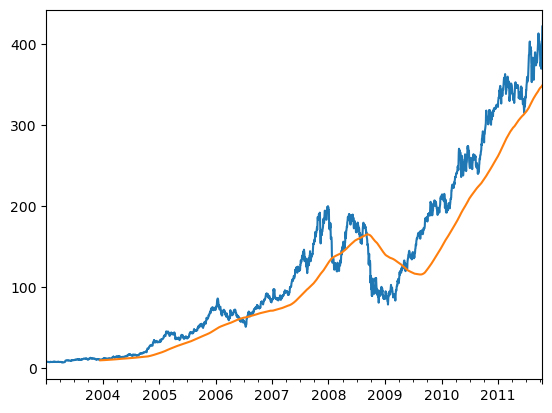

In [266]:
close_px["AAPL"].plot()
close_px["AAPL"].rolling(250).mean().plot()

In [270]:
import matplotlib.pyplot as plt
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [271]:
std250=close_px["AAPL"].pct_change().rolling(250,min_periods=10).std()

In [272]:
std250[5:12]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16    0.009628
2003-01-17    0.013818
Freq: B, Name: AAPL, dtype: float64

<Axes: >

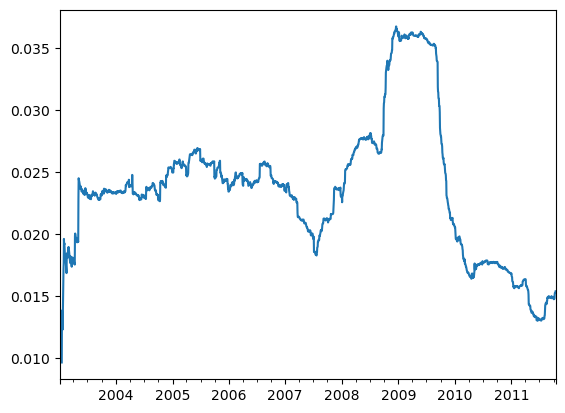

In [273]:
std250.plot()

In [274]:
expanding_mean=std250.expanding().mean()

In [275]:
plt.style.use("grayscale")

<Axes: >

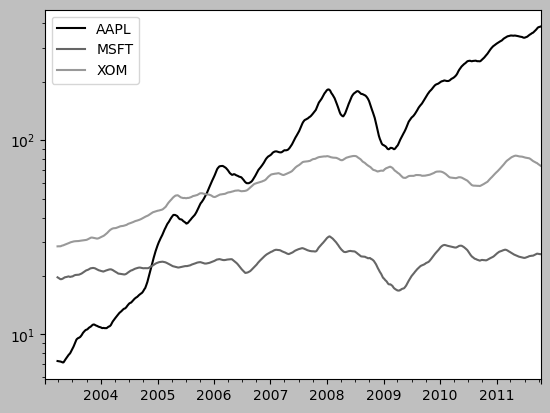

In [276]:
close_px.rolling(60).mean().plot(logy=True)

In [277]:
close_px.rolling("20D").mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


In [278]:
aapl_px=close_px["AAPL"]["2006":"2007"]

In [279]:
ma30=aapl_px.rolling(30,min_periods=20).mean()

In [280]:
ewma30=aapl_px.ewm(span=30).mean()

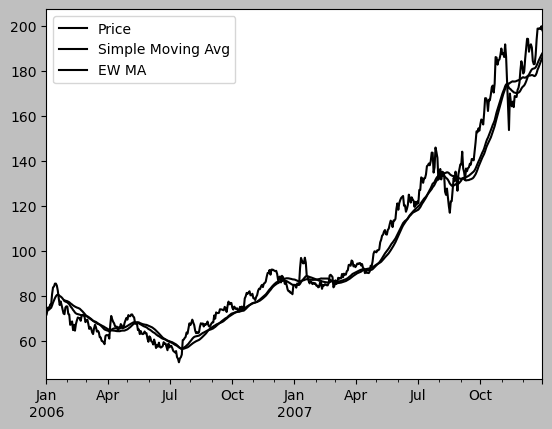

In [283]:
aapl_px.plot(style="k-",label="Price")
ma30.plot(style="k-",label="Simple Moving Avg")
ewma30.plot(style="k-",label="EW MA")
plt.legend()
#k-は黒の実線という意味

In [284]:
spx_px=close_px_all["SPX"]

In [285]:
spx_rets=spx_px.pct_change()

In [286]:
returns=close_px.pct_change()

In [288]:
corr=returns["AAPL"].rolling(125,min_periods=100).corr(spx_rets)

<Axes: >

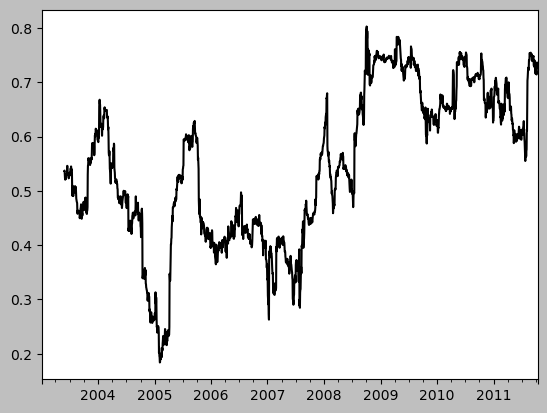

In [289]:
corr.plot()

In [290]:
corr=returns.rolling(125,min_periods=100).corr(spx_rets)

<Axes: >

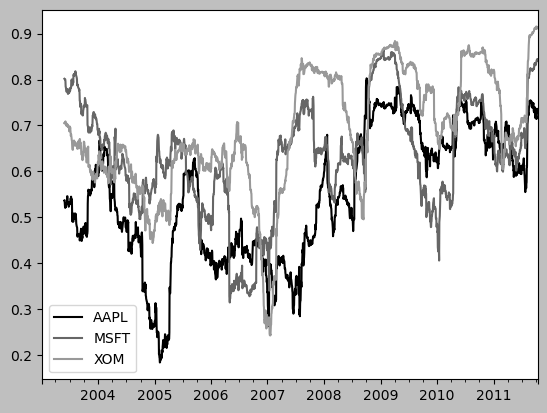

In [291]:
corr.plot()

In [292]:
from scipy.stats import percentileofscore

In [293]:
def score_at_2percent(x):
    return percentileofscore(x,0.02)

In [294]:
result=returns["AAPL"].rolling(250).apply(score_at_2percent)

<Axes: >

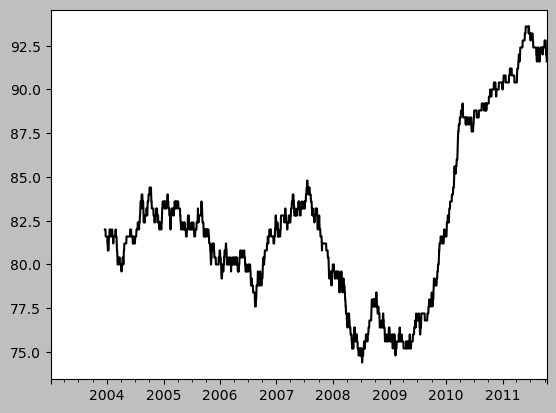

In [295]:
result.plot()